# HW1 — Diabetes Dataset: Neural Network Implementation
DATA-266, Fall 2026

**Personal parameters (SID4 = 6359).** Only parameters the assignment references are used below: `SEED` (splits, init, training) and `HP_ID` (modified-model configuration). `SLICE`, `CLS_A`, `CLS_B` are reported per Section 0.1 but are not referenced by any HW1 task, so they are not otherwise used in this notebook.


In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
# ---- Personal parameters (Section 0.1) ----
SID4  = 6359
SEED  = SID4              # SEED = SID4
SLICE = SID4 % 1000        # not used by HW1 tasks; reported per Section 0.1
HP_ID = SID4 % 6           # -> 5
CLS_A = SID4 % 10          # not used by HW1 tasks; reported per Section 0.1
CLS_B = (CLS_A + 1 + ((SID4 // 10) % 9)) % 10  # not used by HW1 tasks

HP_ID_ARM_NAMES = {0: "Capacity-low", 1: "Capacity-high", 2: "Learning-rate-high",
                    3: "Learning-rate-low", 4: "Schedule-short", 5: "Schedule-long"}

# HW1's exact HP_ID -> configuration mapping (given in the assignment, not derived)
HW1_HP_CONFIGS = {
    0: {"hidden_layers": [32],          "lr": 0.001,  "epochs": 30},
    1: {"hidden_layers": [128, 64, 32], "lr": 0.001,  "epochs": 30},
    2: {"hidden_layers": [64, 32],      "lr": 0.003,  "epochs": 30},
    3: {"hidden_layers": [64, 32],      "lr": 0.0003, "epochs": 30},
    4: {"hidden_layers": [64, 32],      "lr": 0.001,  "epochs": 15},
    5: {"hidden_layers": [64, 32],      "lr": 0.001,  "epochs": 60},
}

BASELINE_CONFIG = {"hidden_layers": [64, 32], "lr": 0.001, "epochs": 30}
MODIFIED_CONFIG = HW1_HP_CONFIGS[HP_ID]

print(f"SID4={SID4}  SEED={SEED}  SLICE={SLICE}  HP_ID={HP_ID} ({HP_ID_ARM_NAMES[HP_ID]})  CLS_A={CLS_A}  CLS_B={CLS_B}")
print("Baseline config:", BASELINE_CONFIG)
print("Modified config (HP_ID {}):".format(HP_ID), MODIFIED_CONFIG)


SID4=6359  SEED=6359  SLICE=359  HP_ID=5 (Schedule-long)  CLS_A=9  CLS_B=5
Baseline config: {'hidden_layers': [64, 32], 'lr': 0.001, 'epochs': 30}
Modified config (HP_ID 5): {'hidden_layers': [64, 32], 'lr': 0.001, 'epochs': 60}


In [18]:
# ---- Global seeding (Section 0.2) ----
import os, random
import numpy as np

def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    except ImportError:
        pass
    try:
        import tensorflow as tf
        tf.random.set_seed(seed)
    except ImportError:
        pass

set_all_seeds(SEED)


## Part 1 — Load and preprocess the diabetes dataset

The provided `diabetes.csv` has **no header row** and 9 columns matching the Pima Indians Diabetes feature set, with features already min-max scaled to roughly [-1, 1] and a binary `Outcome` label in the last column.

In [19]:
import pandas as pd

COLUMNS = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
           "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]

df = pd.read_csv("diabetes.csv", header=None, names=COLUMNS)
print(df.shape)
df.describe().T

(759, 9)


,count,mean,std,min,25%,50%,75%,max
Pregnancies,759.0,-0.407657,0.386260,-0.882353,-0.764706,-0.529412,0.000000,1.0
Glucose,759.0,0.218563,0.306419,-0.557789,-0.005025,0.165829,0.407035,1.0
BloodPressure,759.0,0.176505,0.201287,-0.606557,0.016393,0.180328,0.311475,1.0
SkinThickness,759.0,-0.289735,0.258480,-0.858586,-0.494949,-0.292929,0.000000,1.0
Insulin,759.0,-0.323534,0.375544,-0.966903,-0.716312,0.000000,0.000000,1.0
BMI,759.0,-0.032245,0.205376,-0.457526,-0.178837,-0.034277,0.087929,1.0
DiabetesPedigreeFunction,759.0,-0.663253,0.283056,-0.994876,-0.858241,-0.747225,-0.531597,1.0
Age,759.0,-0.516162,0.400794,-0.966667,-0.866667,-0.633333,-0.233333,1.0
Outcome,759.0,0.653491,0.476171,0.000000,0.000000,1.000000,1.000000,1.0


In [20]:
# Outcome class balance
print(df["Outcome"].value_counts(normalize=True))
df.isna().sum()  # sanity check for missing values

Outcome
1    0.653491
0    0.346509
Name: proportion, dtype: float64


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


## Part 2 — Visualization: correlation matrix and feature distributions

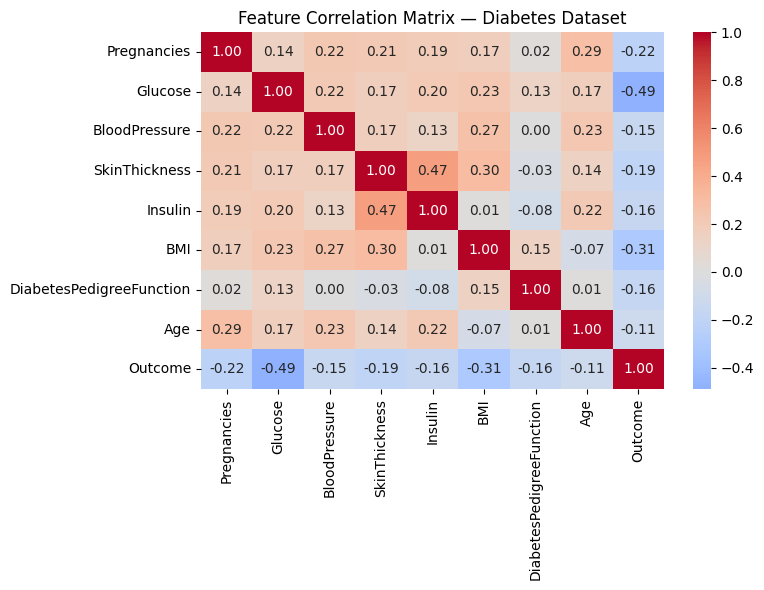

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("figures", exist_ok=True)

plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix — Diabetes Dataset")
plt.tight_layout()
plt.savefig("figures/correlation_matrix.png", dpi=150)
plt.show()

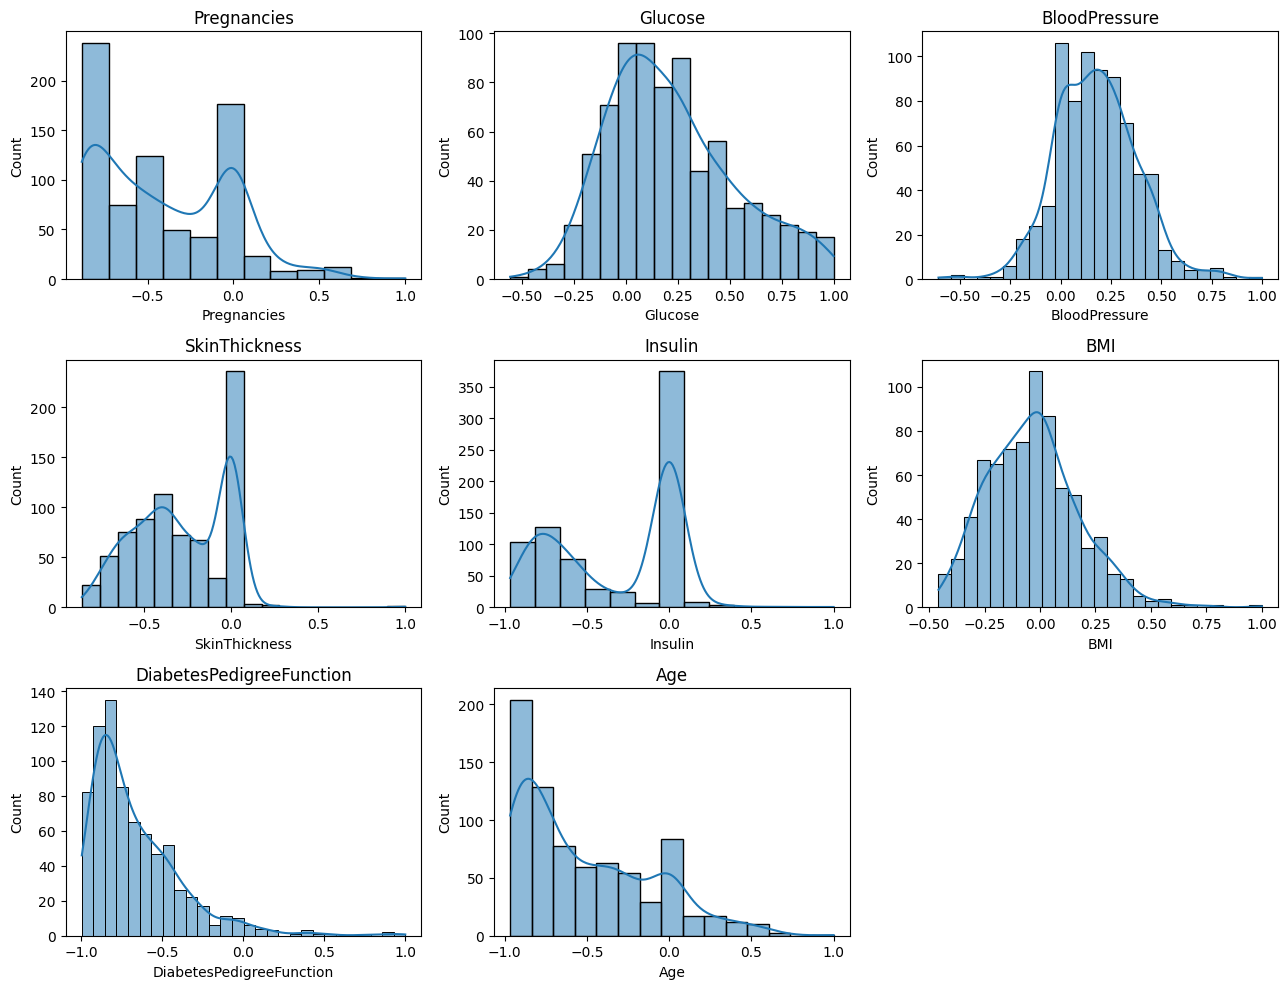

In [22]:
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
for ax, col in zip(axes.flat, COLUMNS):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
fig.delaxes(axes.flat[-1])
plt.tight_layout()
plt.savefig("figures/feature_distributions.png", dpi=150)
plt.show()

## Part 3 — Train / Validation / Test split (70/15/15)

Split once with `random_state=SEED` and reuse the exact same split for every model in both frameworks, per the assignment. Standardization is fit on the training fold only and applied to validation/test to avoid leakage.

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=["Outcome"]).values.astype("float32")
y = df["Outcome"].values.astype("float32")

# 70% train, 30% temp -> split temp into 15%/15% (i.e., 50/50 of the 30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)

scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train).astype("float32")
X_val   = scaler.transform(X_val).astype("float32")
X_test  = scaler.transform(X_test).astype("float32")

print("train:", X_train.shape, " val:", X_val.shape, " test:", X_test.shape)


train: (531, 8)  val: (114, 8)  test: (114, 8)


## Part 4 — PyTorch models

Baseline: hidden layers `[64, 32]`, lr `0.001`, 30 epochs.
Modified (HP_ID = 5, Schedule-long): hidden layers `[64, 32]`, lr `0.001`, **60 epochs**.

In [24]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch device:", device)

class MLP(nn.Module):
    def __init__(self, in_dim, hidden_layers):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden_layers:
            layers += [nn.Linear(prev, h), nn.ReLU()]
            prev = h
        layers += [nn.Linear(prev, 1)]  # logit output
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


def make_loaders(seed, batch_size=32):
    g = torch.Generator().manual_seed(seed)
    train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
    val_ds   = TensorDataset(torch.tensor(X_val),   torch.tensor(y_val))
    test_ds  = TensorDataset(torch.tensor(X_test),  torch.tensor(y_test))
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, generator=g)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader


def train_pytorch_model(hidden_layers, lr, epochs, seed):
    set_all_seeds(seed)
    model = MLP(X_train.shape[1], hidden_layers).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()
    train_loader, val_loader, test_loader = make_loaders(seed)

    history = {"train_loss": [], "val_loss": []}
    for epoch in range(epochs):
        model.train()
        running = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()
            running += loss.item() * xb.size(0)
        train_loss = running / len(train_loader.dataset)

        model.eval()
        running = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                running += loss_fn(model(xb), yb).item() * xb.size(0)
        val_loss = running / len(val_loader.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = (torch.sigmoid(model(xb)) >= 0.5).float()
            correct += (preds == yb).sum().item()
            total += yb.size(0)
    test_acc = correct / total
    return history, test_acc


PyTorch device: cpu


In [25]:
# Multi-seed training: SEED, SEED+1, SEED+2 for baseline and HP_ID-modified models
seeds = [SEED, SEED + 1, SEED + 2]

pt_results = {"baseline": {"accs": [], "history_seed0": None},
              "modified": {"accs": [], "history_seed0": None}}

for name, cfg in [("baseline", BASELINE_CONFIG), ("modified", MODIFIED_CONFIG)]:
    for s in seeds:
        hist, acc = train_pytorch_model(cfg["hidden_layers"], cfg["lr"], cfg["epochs"], s)
        pt_results[name]["accs"].append(acc)
        if s == SEED:
            pt_results[name]["history_seed0"] = hist
    accs = np.array(pt_results[name]["accs"])
    print(f"[PyTorch/{name}] test acc per seed: {accs}  mean={accs.mean():.4f}  std={accs.std():.4f}")


[PyTorch/baseline] test acc per seed: [0.76315789 0.78070175 0.76315789]  mean=0.7690  std=0.0083
[PyTorch/modified] test acc per seed: [0.78070175 0.78947368 0.75438596]  mean=0.7749  std=0.0149


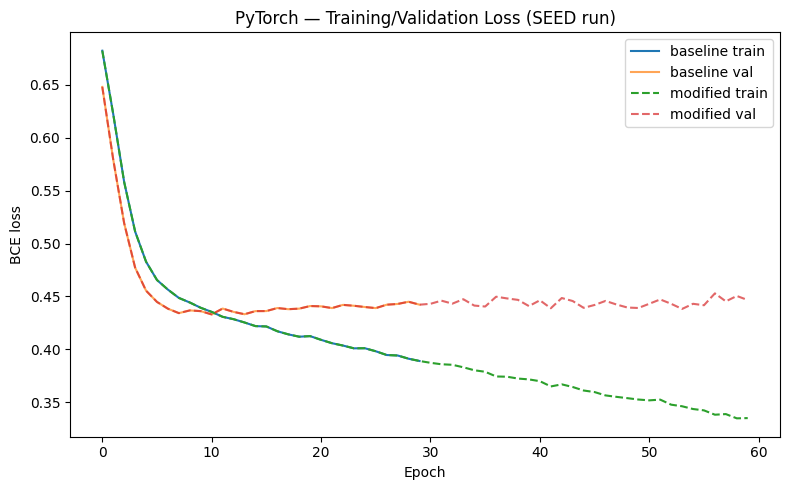

In [26]:
# Loss curves for the SEED run: baseline vs modified (PyTorch)
plt.figure(figsize=(8, 5))
for name, style in [("baseline", "-"), ("modified", "--")]:
    h = pt_results[name]["history_seed0"]
    plt.plot(h["train_loss"], style, label=f"{name} train")
    plt.plot(h["val_loss"], style, label=f"{name} val", alpha=0.7)
plt.xlabel("Epoch"); plt.ylabel("BCE loss")
plt.title("PyTorch — Training/Validation Loss (SEED run)")
plt.legend()
plt.tight_layout()
plt.savefig("figures/pytorch_loss_curves.png", dpi=150)
plt.show()


## Part 5 — TensorFlow models

Same baseline / modified configuration, same split, same metric (test accuracy).

In [27]:
import tensorflow as tf
from tensorflow import keras

print("TensorFlow:", tf.__version__, " GPUs:", tf.config.list_physical_devices('GPU'))

def build_tf_model(hidden_layers, lr, in_dim):
    inputs = keras.Input(shape=(in_dim,))
    x = inputs
    for h in hidden_layers:
        x = keras.layers.Dense(h, activation="relu")(x)
    outputs = keras.layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inputs, outputs)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss="binary_crossentropy", metrics=["accuracy"])
    return model


def train_tf_model(hidden_layers, lr, epochs, seed, batch_size=32):
    set_all_seeds(seed)
    model = build_tf_model(hidden_layers, lr, X_train.shape[1])
    hist = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                      epochs=epochs, batch_size=batch_size, verbose=0)
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    return hist.history, test_acc


TensorFlow: 2.20.0  GPUs: []


In [28]:
tf_results = {"baseline": {"accs": [], "history_seed0": None},
              "modified": {"accs": [], "history_seed0": None}}

for name, cfg in [("baseline", BASELINE_CONFIG), ("modified", MODIFIED_CONFIG)]:
    for s in seeds:
        hist, acc = train_tf_model(cfg["hidden_layers"], cfg["lr"], cfg["epochs"], s)
        tf_results[name]["accs"].append(acc)
        if s == SEED:
            tf_results[name]["history_seed0"] = hist
    accs = np.array(tf_results[name]["accs"])
    print(f"[TensorFlow/{name}] test acc per seed: {accs}  mean={accs.mean():.4f}  std={accs.std():.4f}")


[TensorFlow/baseline] test acc per seed: [0.78070176 0.78947371 0.75438595]  mean=0.7749  std=0.0149
[TensorFlow/modified] test acc per seed: [0.7719298  0.7631579  0.74561405]  mean=0.7602  std=0.0109


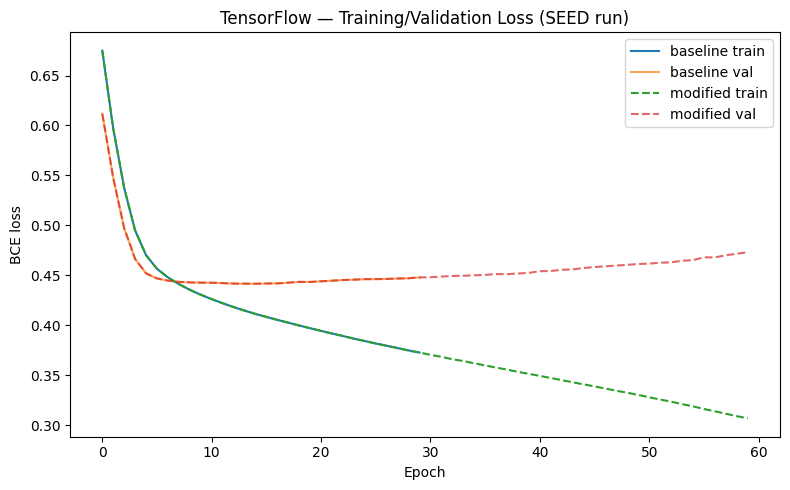

In [29]:
plt.figure(figsize=(8, 5))
for name, style in [("baseline", "-"), ("modified", "--")]:
    h = tf_results[name]["history_seed0"]
    plt.plot(h["loss"], style, label=f"{name} train")
    plt.plot(h["val_loss"], style, label=f"{name} val", alpha=0.7)
plt.xlabel("Epoch"); plt.ylabel("BCE loss")
plt.title("TensorFlow — Training/Validation Loss (SEED run)")
plt.legend()
plt.tight_layout()
plt.savefig("figures/tensorflow_loss_curves.png", dpi=150)
plt.show()

## Part 6 — Comparison table (baseline vs. HP_ID-modified, both frameworks)

In [30]:
rows = []
for framework, results in [("PyTorch", pt_results), ("TensorFlow", tf_results)]:
    for name in ["baseline", "modified"]:
        accs = np.array(results[name]["accs"])
        rows.append({
            "framework": framework,
            "model": name,
            "hidden_layers": (BASELINE_CONFIG if name == "baseline" else MODIFIED_CONFIG)["hidden_layers"],
            "lr": (BASELINE_CONFIG if name == "baseline" else MODIFIED_CONFIG)["lr"],
            "epochs": (BASELINE_CONFIG if name == "baseline" else MODIFIED_CONFIG)["epochs"],
            "test_acc_mean": accs.mean(),
            "test_acc_std": accs.std(),
        })

metrics_df = pd.DataFrame(rows)
metrics_df.to_csv("metrics_nn.csv", index=False)
metrics_df


,framework,model,hidden_layers,lr,epochs,test_acc_mean,test_acc_std
0,PyTorch,baseline,"[64, 32]",0.001,30,0.769006,0.008270
1,PyTorch,modified,"[64, 32]",0.001,60,0.774854,0.014909
2,TensorFlow,baseline,"[64, 32]",0.001,30,0.774854,0.014909
3,TensorFlow,modified,"[64, 32]",0.001,60,0.760234,0.010941


## Part 7 — Written conclusion (HP_ID = 5, Schedule-long: 60 vs. 30 epochs)

Baseline (30 epochs) test accuracy: 0.7690 (PyTorch), 0.7749 (TensorFlow)
Modified/HP_ID=5 (60 epochs) test accuracy: 0.7749 (PyTorch), 0.7602 (TensorFlow)
Reading the loss curves: in both frameworks, the modified model's training loss keeps decreasing through epoch 60 (down to ~0.32 in PyTorch, ~0.30 in TensorFlow), while validation loss plateaus around epoch 15–20 and then drifts flat-to-rising — most visibly in TensorFlow, where validation loss rises from ~0.45 to ~0.50 between epoch 30 and 60. This is a classic overfitting pattern: the extra epochs improve training fit without improving (and in TensorFlow, while hurting) generalization.
Conclusion: doubling the epoch budget did not reliably help. In PyTorch, the modified model's mean accuracy (0.7749) was only 0.0059 higher than baseline (0.7690) — smaller than the modified model's own std (0.0149), so not a reliable effect. In TensorFlow, the modified model's mean accuracy (0.7602) was actually 0.0147 lower than baseline (0.7749), a drop roughly equal to the measured std — consistent with the overfitting visible in the loss curves. Net effect: Schedule-long (HP_ID=5) offered no real benefit here and plausibly hurt in TensorFlow.

In [34]:
!git config --global user.email "manjot.kaur02@sjsu.edu"
!git config --global user.name "Manjot Kaur"

from google.colab import userdata
import os
os.environ["GITHUB_TOKEN"] = userdata.get('GITHUB_TOKEN')  # set this secret first via the key icon on the left sidebar

SecretNotFoundError: Secret GITHUB_TOKEN does not exist.